# LLM Inference from Scratch

This notebook documents my hands-on journey learning how LLM inference works under the hood — from implementing KV caching to quantizing models for deployment.

Each phase builds a technique from scratch, benchmarks it, and ends with what I took away from the exercise.

**Toy model / GPT-2** for Phases 1–5 (fundamentals) | **Qwen2.5-1.5B-Instruct** for Phases 6–7 (deployment decisions)  
**GPU:** T4 (Google Colab) | **Goal:** Pick the optimal inference stack for a children's story generation service

In [1]:
!nvidia-smi

Tue Mar  3 23:41:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Phase - 1: The importance of KV caching

1.1 : Single Head Attention Implementation

In [4]:
class SingleHeadAttention(nn.Module):
  def __init__(self,d_model):
    super().__init__()
    self.d_model = d_model

    self.W_q = nn.Linear(d_model, d_model, bias=False)
    self.W_k = nn.Linear(d_model, d_model, bias=False)
    self.W_v = nn.Linear(d_model, d_model, bias=False)

  def forward(self,x, past_k = None, past_v = None, use_cache = False):
    B, T, C = x.shape

    Q = self.W_q(x)
    K = self.W_k(x)
    V = self.W_v(x)

    # This is the entire KV cache idea
    if use_cache and past_k is not None:
      # here past_k has the shape[B, t-1, d] and K has the shape[B,1,d]
      K = torch.cat([past_k, K], dim=1)
      V = torch.cat([past_v, V], dim=1)

    T_total = K.size(1)

    attention_scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_model)

    if T > 1 :
      # Use x.device to ensure mask is on the same device as input
      mask = torch.triu(torch.ones(T, T_total, device=x.device), diagonal = T_total - T + 1).bool()
      attention_scores = attention_scores.masked_fill(mask, float('-inf'))

    attn_weights = torch.softmax(attention_scores, dim=-1)

    attn_output = attn_weights @ V

    return attn_output, K , V

class SimpleInferenceModel(nn.Module):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.attention = SingleHeadAttention(d_model)
    self.head = nn.Linear(d_model, vocab_size)

  def forward(self, idx, past_key_values=None, use_cache=False):
    x = self.embedding(idx)

    past_k, past_v = (None, None)

    if past_key_values is not None:
      past_k, past_v = past_key_values

    attn_out, k, v = self.attention(x, past_k, past_v, use_cache)
    logits =self.head(attn_out)

    return logits, (k, v)

1.2 : Naive Autoregressive Decoding ( No KV Cache)

In [5]:
@torch.no_grad()
def decode_no_cache(model, input_ids, max_new_tokens):
  model.eval()
  generated = input_ids

  if input_ids.device.type == 'cuda':
      torch.cuda.synchronize()
  start_time = time.time()

  for _ in range(max_new_tokens):
    logits, _ = model(generated)

    next_token_logits = logits[:, -1, :]

    next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

    generated = torch.cat((generated, next_token), dim=-1)

  if input_ids.device.type == 'cuda':
    torch.cuda.synchronize()
  total_time = time.time() - start_time
  return generated, total_time

1.3 : KV Cached Decoder

In [6]:
@torch.no_grad()
def decode_with_cache(model, input_ids, max_new_tokens):
  model.eval()
  generated = input_ids
  past_key_values = None
  peak_kv_bytes = 0

  if input_ids.device.type == 'cuda':
    torch.cuda.synchronize()
  start_time = time.time()

  for i in range(max_new_tokens):
    curr_input = generated if i == 0 else generated[:, -1:]

    logits, past_key_values = model(curr_input, past_key_values, use_cache = True)
    
    # Measuring Kv cache size directly from tensor shapes
    k, v = past_key_values
    kv_bytes = k.nelement() * k.element_size() + v.nelement() * v.element_size()
    if kv_bytes > peak_kv_bytes:
      peak_kv_bytes = kv_bytes


    next_token_logits = logits[: , -1, :]
    next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

    generated = torch.cat((generated, next_token), dim=-1)

  if input_ids.device.type == 'cuda':
    torch.cuda.synchronize()
  total_time = time.time() - start_time
  return generated, total_time, peak_kv_bytes / 1024 ** 2  

1.4 : Testing different context lengths

In [7]:
# Initialization
vocab_size = 1000
d_model = 512
model = SimpleInferenceModel(vocab_size, d_model).to(device)

In [ ]:
# Warmup run (not measured)
warmup_ids = torch.randint(0, vocab_size, (1, 5)).to(device)
_ = decode_no_cache(model, warmup_ids, 10)

Tokens     | Naked (s)    | Cached (s)   | Speedup   
-------------------------------------------------------
256        | 0.1684       | 0.0986       | 1.71x
512        | 0.2809       | 0.1983       | 1.42x
1024       | 0.8449       | 0.4069       | 2.08x
2048       | 4.0329       | 0.8826       | 4.57x


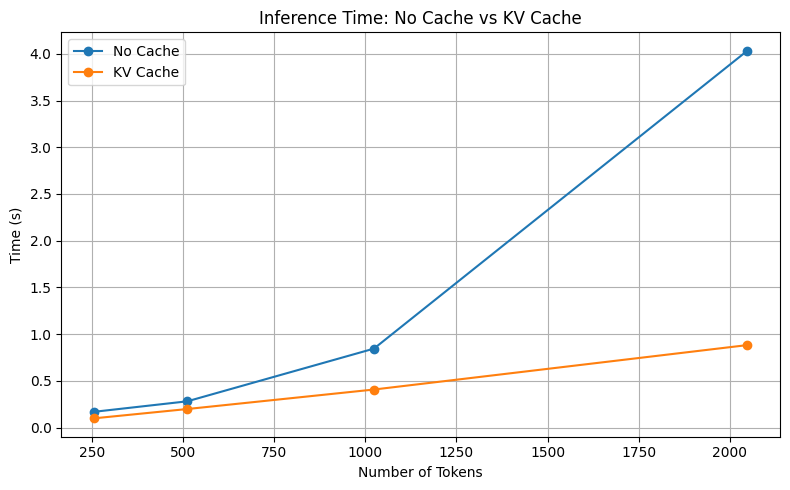

In [24]:
def run_and_plot_comparison(lengths=[256, 512, 1024, 2048]):
    naked_times = []
    cached_times = []

    print(f"{'Tokens':<10} | {'Naked (s)':<12} | {'Cached (s)':<12} | {'Speedup':<10}")
    print("-" * 55)

    for T in lengths:
        input_ids = torch.randint(0, vocab_size, (1, 5)).to(device)

        _, t_naked = decode_no_cache(model, input_ids, T)
        _, t_cached, _ = decode_with_cache(model, input_ids, T)
        
        naked_times.append(t_naked)
        cached_times.append(t_cached)

        speedup = t_naked / t_cached
        print(f"{T:<10} | {t_naked:<12.4f} | {t_cached:<12.4f} | {speedup:.2f}x")

    # Plotting Inference Time Comparison
    plt.figure(figsize=(8, 5))
    plt.plot(lengths, naked_times, marker='o', label='No Cache')
    plt.plot(lengths, cached_times, marker='o', label='KV Cache')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Time (s)')
    plt.title('Inference Time: No Cache vs KV Cache')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

run_and_plot_comparison()

### Some interesting things I learnt

**The KV Cache Idea:**  
Without caching, at step $t$ we recompute keys and values for all $t$ previous tokens — $O(t^2)$ total work across the full decode.  
With caching, we store $K$ and $V$ from prior steps and only compute the new token's $Q$, $K$, $V$ — reducing each step to $O(t)$, and total decode to $O(n^2)$ → $O(n)$ per step.

**What the results show:**

| Tokens | Naked (s) | Cached (s) | Speedup |
|--------|-----------|------------|---------|
| 256    | 0.17      | 0.10       | 1.71×   |
| 512    | 0.28      | 0.20       | 1.42×   |
| 1024   | 0.84      | 0.41       | 2.08×   |
| 2048   | 4.03      | 0.88       | 4.57×   |

- At **shorter sequences (256–512)**, the speedup is modest (~1.4–1.7×) because the per-token computation is small and Python loop overhead dominates both approaches equally.
- At **longer sequences (1024–2048)**, the gap explodes — naked decode's $O(t)$ recomputation per step compounds quadratically, while cached decode stays linear. The 4.57× at 2048 tokens is the real story.
- The slight **dip from 1.71× to 1.42×** between 256 and 512 is normal variance on a toy model — the absolute times are so small (0.1–0.2s) that minor fluctuations in GPU scheduling shift the ratio.

**On warmup:** The benchmark includes a warmup call before timing. Try commenting out the warmup line and rerunning — you'll see the first data point inflate dramatically due to one-time CUDA kernel compilation, producing a misleading graph.

# Phase - 2 : The importance of Peak Utilization

In [8]:
# Sanity check: clear GPU before Phase 2
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU memory: 7 MB allocated, 24 MB reserved


2.1 : Trying to hit PEAK FLOPS with the help of batching for our naive model

In [9]:
@torch.no_grad()
def benchmark_batch_scaling(model, device, batch_sizes, prompt_len = 5, max_new_tokens=128, vocab_size = 1000):
  results = []

  print(f"{'Batch':<8} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Max VRAM (MB)':<14}")
  print("-" * 60)

  for B in batch_sizes:

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    input_ids = torch.randint(0, vocab_size, (B, prompt_len)).to(device)

    _= decode_with_cache(model, input_ids, 10)

    torch.cuda.synchronize()
    start_time = time.time()

    _, total_time, _ = decode_with_cache(model, input_ids, max_new_tokens)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    total_tokens = B * max_new_tokens
    tokens_per_second = total_tokens / total_time

    max_mem = torch.cuda.max_memory_allocated() / (1024 * 1024)

    print(f"{B:<8} | {total_time:<10.4f} | {tokens_per_second:<12.2f} | {max_mem:<14.2f}")

    results.append((B, tokens_per_second, max_mem))

  return results

In [10]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64]

results = benchmark_batch_scaling(
    model,
    device,
    batch_sizes=batch_sizes,
    prompt_len=5,
    max_new_tokens=5000,
)

Batch    | Time (s)   | Tokens/sec   | Max VRAM (MB) 
------------------------------------------------------------
1        | 2.3934     | 2089.06      | 56.12         
2        | 2.4636     | 4059.03      | 96.21         
4        | 3.5865     | 5576.50      | 176.38        
8        | 5.7428     | 6965.25      | 329.44        
16       | 11.2379    | 7118.78      | 642.85        
32       | 22.2007    | 7206.97      | 1269.76       
64       | 46.2352    | 6921.13      | 2526.19       


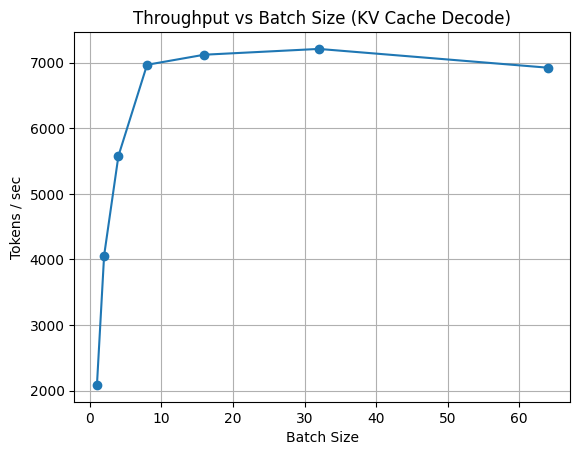

In [11]:
Bs = [r[0] for r in results]
throughputs = [r[1] for r in results]

plt.figure()
plt.plot(Bs, throughputs, marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Tokens / sec")
plt.title("Throughput vs Batch Size (KV Cache Decode)")
plt.grid(True)
plt.show()

### Observation

Throughput plateaus around batch=32 and slightly drops at batch=64, even though we're only using 2.5GB of 16GB VRAM.

Our toy model (vocab=1000, d=512) is so small that each matmul finishes almost instantly. The GPU never gets close to its **compute FLOP limit** — instead, the bottleneck becomes **memory bandwidth and kernel launch overhead**. The model isn't dense enough for the GPU to consider each operation "worth" fully spinning up its cores. Most of the time is spent moving tiny tensors around and waiting for the next Python loop iteration, not doing actual math.

To see real GPU utilization and true batching gains, we need a chunkier model. Let's test with **GPT-2 (124M parameters)** — ~250× larger than our toy model — where each matmul actually gives the GPU something meaningful to chew on.

2.2 :Stress Testing GPU with GPT-2

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [14]:
# Sanity check: clear GPU before implementing the GPT-2
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU memory: 16 MB allocated, 26 MB reserved


In [15]:
!nvidia-smi

Fri Feb 27 19:47:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             41W /   70W |     157MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
model_name = 'gpt2'
gpt2_tokenizer = AutoTokenizer.from_pretrained(model_name)
gpt2_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
gpt2_model.eval()

max_new_tokens = 1000

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
@torch.no_grad()
def gpt2_decode_with_cache(model, input_ids, max_new_tokens):
    past = None
    generated = input_ids

    for step in range(max_new_tokens):
        if past is None:
            outputs = model(generated, use_cache=True)
        else:
            outputs = model(
                generated[:, -1:],
                past_key_values=past,
                use_cache=True
            )

        logits = outputs.logits
        past = outputs.past_key_values

        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)

    return generated

In [18]:
def gpt2_benchmark_batch(batch_size):
    torch.cuda.empty_cache()

    prompt = "Hello, this is a test prompt."
    input_ids = gpt2_tokenizer(prompt, return_tensors="pt").input_ids
    input_ids = input_ids.repeat(batch_size, 1).to(device)

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    start = time.time()
    _ = gpt2_decode_with_cache(gpt2_model, input_ids, max_new_tokens)
    torch.cuda.synchronize()
    total_time = time.time() - start

    total_tokens = batch_size * max_new_tokens
    tokens_per_sec = total_tokens / total_time
    peak_mem = torch.cuda.max_memory_allocated() / 1024**2

    return total_time, tokens_per_sec, peak_mem

In [19]:
batches = [1, 2, 4, 8, 16, 32]

print(f"{'Batch':<8} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Max VRAM (MB)':<15}")
print("-" * 60)

for B in batches:
    t, tok_s, mem = gpt2_benchmark_batch(B)
    print(f"{B:<8} | {t:<10.4f} | {tok_s:<12.2f} | {mem:<15.2f}")

Batch    | Time (s)   | Tokens/sec   | Max VRAM (MB)  
------------------------------------------------------------
1        | 9.5657     | 104.54       | 577.94         
2        | 8.0830     | 247.43       | 651.91         
4        | 9.4912     | 421.44       | 802.04         
8        | 12.6673    | 631.55       | 1106.17        
16       | 18.5600    | 862.07       | 1707.44        
32       | 32.8141    | 975.19       | 2870.98        


### Arithmetic Intensity Analysis — Is This Memory-Bound or Compute-Bound?

GPT-2 has 124M parameters in FP32 = **496 MB of weights** loaded every decode step.

**Arithmetic Intensity** = FLOPs per step / Bytes loaded per step

$$AI = \frac{B \times 2 \times 124M}{496M} = \frac{B}{2} \text{ FLOPs/byte}$$

The T4's **ridge point** (where compute and memory bandwidth are equally bottlenecked) is:

$$\frac{8.1 \text{ TFLOPS}}{320 \text{ GB/s}} \approx 25.3 \text{ FLOPs/byte}$$

At batch=32, our AI is only **16** — still below the ridge point. We are **memory-bandwidth bound at every batch size we tested**. The GPU spends most of its time loading weights from VRAM, not doing math.

This is why throughput scales ~9× from batch 1→32, not 32× — the weight loads are amortized, but growing KV cache reads eat into the bandwidth savings. To reach compute-bound territory, we'd need batch ≈ 51+.

**Takeaway:** For autoregressive decode with a model this size on T4, we're always bottlenecked by how fast we can read weights from memory — not by how fast we can multiply matrices.

In [23]:
# Pushing higher: can we reach compute-bound territory?
large_batches = [64, 128, 256]

print(f"{'Batch':<8} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Max VRAM (MB)':<15} | {'AI (FLOPs/byte)':<16}")
print("-" * 75)

for B in large_batches:
    try:
        t, tok_s, mem = gpt2_benchmark_batch(B)
        ai = B / 2  # Arithmetic Intensity = B * 2 * 124M / (496M bytes)
        print(f"{B:<8} | {t:<10.4f} | {tok_s:<12.2f} | {mem:<15.2f} | {ai:<16.1f}")
    except RuntimeError as e:
        print(f"{B:<8} | OOM — KV cache too large for 16GB T4")
        break

Batch    | Time (s)   | Tokens/sec   | Max VRAM (MB)   | AI (FLOPs/byte) 
---------------------------------------------------------------------------
64       | 66.4596    | 962.99       | 5237.99         | 32.0            
128      | 136.8725   | 935.18       | 9982.63         | 64.0            
256      | OOM — KV cache too large for 16GB T4


### Have We Reached Compute-Bound?

No. Even though AI > 25.3 at batch=64+, throughput doesn't plateau — it **declines** (975 → 963 → 935 tok/s). At true compute saturation, throughput would hold steady as the GPU is fully utilized.

The issue: our AI formula only accounted for **weight reads**. At batch=64, the KV cache is 5.2 GB — over 10× the weight size — and must be read every decode step. This extra bandwidth demand keeps us memory-bound, just with a different bottleneck: **KV cache reads instead of weight reads**.

This motivates the next phases — techniques to reduce what we store and move (sliding window, paged attention, flash attention).

# Phase - 3 : Sliding Window Attention for Efficient Decode

In [35]:
# Sanity check: clear GPU before a new phase implementation
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU memory: 518 MB allocated, 552 MB reserved


In [36]:
!nvidia-smi

Fri Feb 27 20:33:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             40W /   70W |     683MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

We redefine `SingleHeadAttention` and `SimpleInferenceModel` here with an optional `window_size` parameter that caps how far back the model attends during cached decode.

In [27]:
class SingleHeadAttention(nn.Module):
  def __init__(self, d_model, window_size = None):
    super().__init__()
    self.d_model = d_model
    self.window_size = window_size

    self.W_q = nn.Linear(d_model, d_model, bias = False)
    self.W_k = nn.Linear(d_model, d_model, bias = False)
    self.W_v = nn.Linear(d_model, d_model, bias = False)

  def forward(self, x, past_k = None, past_v = None, use_cache = False):
    B, T, C = x.shape

    Q = self.W_q(x)
    K = self.W_k(x)
    V = self.W_v(x)

    if use_cache and past_k is not None:
      K = torch.cat([past_k,K], dim = 1)
      V = torch.cat([past_v,V], dim = 1)

    if use_cache and self.window_size is not None:
      if K.size(1) > self.window_size:
        K = K[:, -self.window_size:, :]
        V = V[:, -self.window_size:, :]

    attention_scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_model)
    atten_weights = torch.softmax(attention_scores, dim = -1)

    attn_output = atten_weights @ V

    return attn_output, K, V

In [28]:
class SimpleInferenceModel(nn.Module):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.attention = SingleHeadAttention(d_model)
    self.head = nn.Linear(d_model, vocab_size)

  def forward(self, idx, past_key_values=None, use_cache=False):
    x = self.embedding(idx)

    past_k, past_v = (None, None)

    if past_key_values is not None:
      past_k, past_v = past_key_values

    attn_out, k, v = self.attention(x, past_k, past_v, use_cache)
    logits =self.head(attn_out)

    return logits, (k, v)

In [29]:
vocab_size = 1000
d_model = 512

In [30]:
model_full = SimpleInferenceModel(vocab_size, d_model).to(device)

model_window = SimpleInferenceModel(vocab_size, d_model).to(device)
model_window.attention.window_size = 128

seq_lengths=[512,1024,2048,5096]

In [31]:
def benchmark_sequence_growth(model, batch_size = 16, lengths=[128,256,512,1024]):
  results = []

  for T in lengths:
    input_ids = torch.randint(0, vocab_size, (batch_size, 5)).to(device)

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    start = time.time()

    _,total_time, peak_kv_mb = decode_with_cache(model, input_ids, T)

    torch.cuda.synchronize()
    peak_mem = torch.cuda.memory_allocated() / 1024**2

    time_per_token = total_time/T

    results.append((T, total_time, time_per_token, peak_mem, peak_kv_mb))

    print(f"T={T:<5} | Total={total_time:.3f}s | "
              f"PerToken={time_per_token:.6f}s | "
              f"VRAM={peak_mem:.2f}MB | KV Cache={peak_kv_mb:.2f}MB")

  return results

In [37]:
# Warmup both models
warmup_ids = torch.randint(0, vocab_size, (16, 5)).to(device)
_ = decode_with_cache(model_full, warmup_ids, 10)
_ = decode_with_cache(model_window, warmup_ids, 10)

In [38]:
print("===== FULL ATTENTION =====")
results_full = benchmark_sequence_growth(model_full, lengths = seq_lengths)

print("\n===== SLIDING WINDOW =====")
results_window = benchmark_sequence_growth(model_window, lengths = seq_lengths)

===== FULL ATTENTION =====
T=512   | Total=0.247s | PerToken=0.000483s | VRAM=518.04MB | KV Cache=32.25MB
T=1024  | Total=0.609s | PerToken=0.000595s | VRAM=518.10MB | KV Cache=64.25MB
T=2048  | Total=2.049s | PerToken=0.001000s | VRAM=518.23MB | KV Cache=128.25MB
T=5096  | Total=11.587s | PerToken=0.002274s | VRAM=518.60MB | KV Cache=318.75MB

===== SLIDING WINDOW =====
T=512   | Total=0.233s | PerToken=0.000455s | VRAM=518.04MB | KV Cache=8.00MB
T=1024  | Total=0.437s | PerToken=0.000427s | VRAM=518.10MB | KV Cache=8.00MB
T=2048  | Total=0.871s | PerToken=0.000425s | VRAM=518.23MB | KV Cache=8.00MB
T=5096  | Total=2.150s | PerToken=0.000422s | VRAM=518.60MB | KV Cache=8.00MB


Visualizing our results

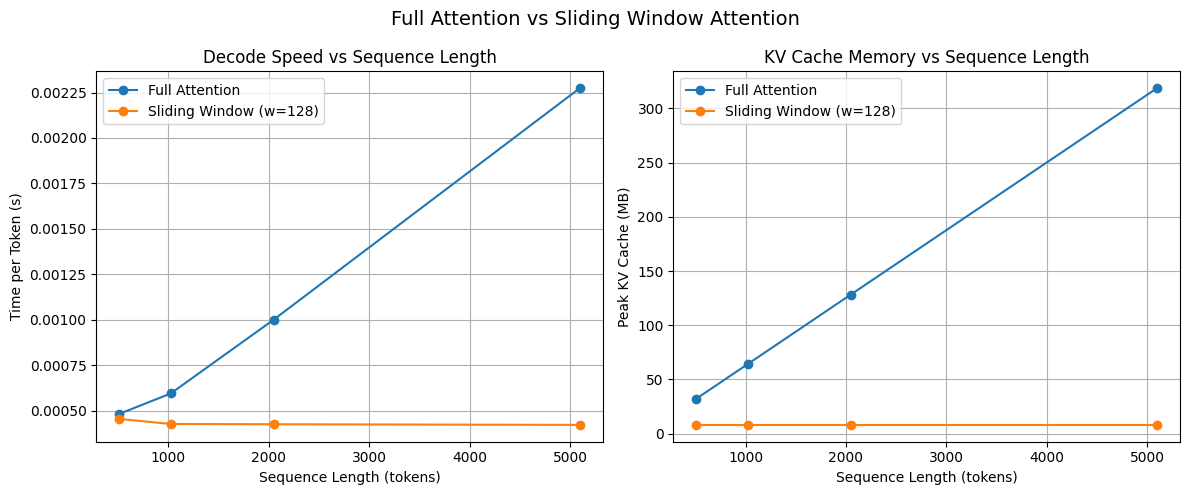

In [39]:
lengths = [r[0] for r in results_full]

time_per_token_full = [r[2] for r in results_full]
time_per_token_window = [r[2] for r in results_window]

kv_full = [r[4] for r in results_full]
kv_window = [r[4] for r in results_window]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(lengths, time_per_token_full,   marker='o', label='Full Attention')
axes[0].plot(lengths, time_per_token_window, marker='o', label='Sliding Window (w=128)')
axes[0].set_xlabel('Sequence Length (tokens)')
axes[0].set_ylabel('Time per Token (s)')
axes[0].set_title('Decode Speed vs Sequence Length')
axes[0].legend()
axes[0].grid(True)


axes[1].plot(lengths, kv_full,   marker='o', label='Full Attention')
axes[1].plot(lengths, kv_window, marker='o', label='Sliding Window (w=128)')
axes[1].set_xlabel('Sequence Length (tokens)')
axes[1].set_ylabel('Peak KV Cache (MB)')
axes[1].set_title('KV Cache Memory vs Sequence Length')
axes[1].legend()
axes[1].grid(True)


plt.suptitle('Full Attention vs Sliding Window Attention', fontsize=14)
plt.tight_layout()
plt.show()

### What I Learned — Phase 3

In Phase 2 we saw that the **KV cache is the bandwidth bottleneck** — it grows with sequence length and eats into memory bandwidth at larger batches. Sliding window directly attacks this: cap the cache at a fixed size, regardless of how long the sequence gets.

**Results after warmup:**
- At 512 tokens, both are nearly identical (~0.46ms/token) — the cache is small enough that full attention isn't hurting yet.
- At 5096 tokens, full attention slows to 2.27ms/token while sliding window holds steady at 0.42ms/token — a **5.4× speedup**, with the KV cache fixed at 8 MB vs 319 MB.

**The downside:** This is not free. Sliding window physically discards keys and values older than 128 steps — the model cannot reference anything beyond that window. For tasks requiring long-range context (e.g., summarizing a full document, or referring back to a character introduced paragraphs ago), this is a real quality loss. For short outputs like our children's stories (~100–200 tokens), the window never becomes a constraint.

### But then I thought... what if we increase our Window sizes....Sweeping across different window sizes

In [44]:
# Sanity check: clear GPU before a new phase implementation
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU memory: 518 MB allocated, 552 MB reserved


In [40]:
!nvidia-smi

Fri Feb 27 20:36:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             31W /   70W |   12449MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
FIXED_LEN = 4096
BATCH_SIZE = 16
window_sizes = [32, 64, 128, 256, None]

sweep_results = []

print(f"{'Window':<10} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Peak KV (MB)':<14}")
print("-" * 60)

for ws in window_sizes:
    m = SimpleInferenceModel(vocab_size, d_model).to(device)
    m.attention.window_size = ws

    input_ids = torch.randint(0, vocab_size, (BATCH_SIZE, 5)).to(device)
    _, total_time, peak_kv_mb = decode_with_cache(m, input_ids, FIXED_LEN)

    tpt = total_time / FIXED_LEN
    label = str(ws) if ws is not None else "Full"
    sweep_results.append((label, total_time, tpt, peak_kv_mb))

    print(f'{label:<10} | {total_time:<10.4f} | {tpt:<12.6f} | {peak_kv_mb:<14.2f}')

    del m
    torch.cuda.empty_cache()

Window     | Time (s)   | Tokens/sec   | Peak KV (MB)  
------------------------------------------------------------
32         | 2.0774     | 0.000408     | 2.00          
64         | 2.0593     | 0.000404     | 4.00          
128        | 2.0759     | 0.000407     | 8.00          
256        | 2.3995     | 0.000471     | 16.00         
Full       | 11.6967    | 0.002295     | 318.75        


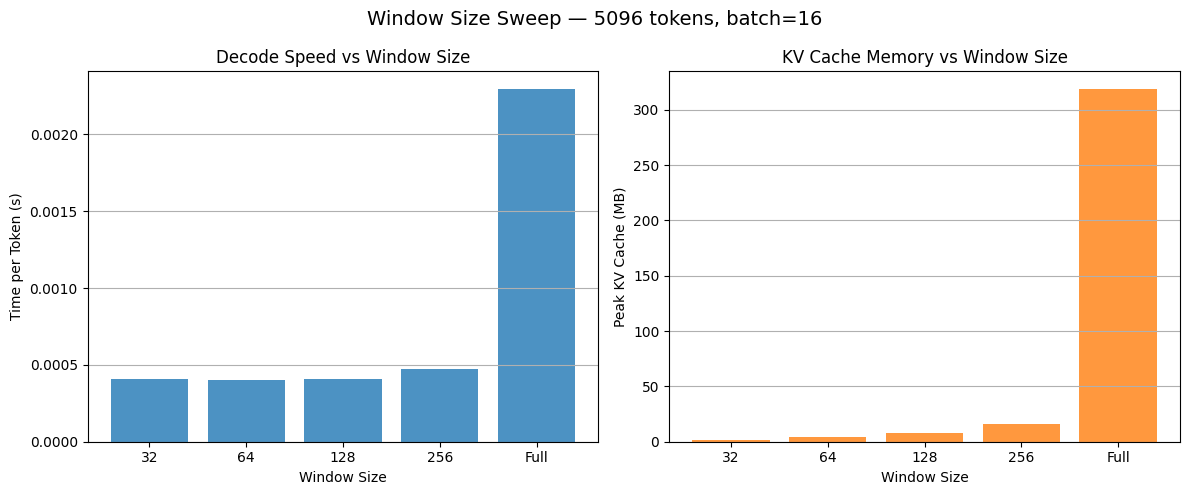

In [46]:
labels = [r[0] for r in sweep_results]
tpts   = [r[2] for r in sweep_results]
kvs    = [r[3] for r in sweep_results]
x      = range(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: time per token
axes[0].bar(x, tpts, color='tab:blue', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Window Size')
axes[0].set_ylabel('Time per Token (s)')
axes[0].set_title('Decode Speed vs Window Size')
axes[0].grid(axis='y')

# Right: KV cache memory
axes[1].bar(x, kvs, color='tab:orange', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Window Size')
axes[1].set_ylabel('Peak KV Cache (MB)')
axes[1].set_title('KV Cache Memory vs Window Size')
axes[1].grid(axis='y')

plt.suptitle(f'Window Size Sweep — {FIXED_LEN} tokens, batch={BATCH_SIZE}', fontsize=14)
plt.tight_layout()
plt.show()

**Speed is flat from window=32 to 128** — the KV cache is so small (2–8 MB) that reading it takes negligible time regardless of window size. The GPU doesn't care whether it reads 2 MB or 8 MB; both are tiny.

At **window=256**, there's a slight bump (0.41 → 0.47 ms/token) — the 16 MB cache is just starting to show up in memory read time.

Then **Full attention explodes** to 2.3 ms/token — the 319 MB cache dominates every decode step.

**The takeaway:** KV cache memory grows linearly with window size, but speed only starts degrading once the cache is large enough to meaningfully compete for bandwidth. In the case of the toy model that we implemented, windows up to ~128 give identical speed and hence we can increase context range without any latency cost.

# Phase - 4 : Flash Attention

In [57]:
# Sanity check: clear GPU before a new phase implementation
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU memory: 519 MB allocated, 554 MB reserved


In [58]:
!nvidia-smi

Fri Feb 27 20:46:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             28W /   70W |     687MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [51]:
class SingleHeadAttentionFlash(nn.Module):
    def __init__(self, d_model, num_heads=8):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias = False)
        self.W_k = nn.Linear(d_model, d_model, bias = False)
        self.W_v = nn.Linear(d_model, d_model, bias = False)

    def forward(self, x, past_k = None, past_v = None, use_cache = True):
        B, T, C = x.shape
        

        Q = self.W_q(x).view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        if use_cache and past_k is not None:
            K = torch.cat([past_k, K], dim = 2)
            V = torch.cat([past_v, V], dim = 2)
            
        if T > 1:
            is_causal_flag = True
        else:            
            is_causal_flag = False
        
        # To check if flash attention is being used, you can print the type of attn_output:
        # with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=False):
        attn_output = F.scaled_dot_product_attention(Q, K, V, is_causal=is_causal_flag)
        
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, self.d_model)

        return attn_output, K, V



In [52]:
class SimpleInferenceModelFlash(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attention = SingleHeadAttentionFlash(d_model)
        self.head = nn.Linear(d_model, vocab_size)
        
    def forward(self, input_idx, past_key_values = None, use_cache = True):
        x = self.embedding(input_idx)
        
        past_k, past_v = (None, None)
        
        if past_key_values is not None and use_cache:
            past_k, past_v = past_key_values
        
        attn_out, k, v = self.attention(x, past_k, past_v, use_cache)
        logits = self.head(attn_out)

        return logits, (k, v)

In [53]:
def benchmark_flash_vs_naive_attn(lengths=[512,1024,2048,4096], batch_size=16):
    model_naive = SimpleInferenceModel(vocab_size, d_model).to(device)
    model_flash = SimpleInferenceModelFlash(vocab_size, d_model).to(device).half()

    results_naive ,results_flash = [], []

    print(f"{'Length':<8} | {'Naive TPT':<12} | {'Flash TPT':<12} | {'Naive VRAM':<12} | {'Flash VRAM':<12}")
    print("-" * 70)

    for T in lengths:
        input_idx = torch.randint(0, vocab_size, (batch_size, 5), device=device)

        #Naive (float32)
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _, t_naive, _ = decode_with_cache(model_naive, input_idx, T)
        naive_vram = torch.cuda.max_memory_allocated() / 1024**2

        # Flash (float16)
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _, t_flash, _ = decode_with_cache(model_flash, input_idx, T)
        flash_vram = torch.cuda.max_memory_allocated() / 1024**2

        naive_tpt = t_naive / T
        flash_tpt = t_flash / T

        results_naive.append((T, t_naive, naive_tpt, naive_vram))
        results_flash.append((T, t_flash, flash_tpt, flash_vram))

        print(f"{T:<8} | {naive_tpt:<12.6f} | {flash_tpt:<12.6f} | {naive_vram:<12.2f} | {flash_vram:<12.2f}")

    return results_naive, results_flash

In [59]:
# Warmup both models
model_naive_warmup = SimpleInferenceModel(vocab_size, d_model).to(device)
model_flash_warmup = SimpleInferenceModelFlash(vocab_size, d_model).to(device).half()
warmup_ids = torch.randint(0, vocab_size, (16, 5), device=device)

_ = decode_with_cache(model_naive_warmup, warmup_ids, 10)
_ = decode_with_cache(model_flash_warmup, warmup_ids, 10)

del model_naive_warmup, model_flash_warmup
torch.cuda.empty_cache()

In [60]:
results_naive, results_flash = benchmark_flash_vs_naive_attn()

Length   | Naive TPT    | Flash TPT    | Naive VRAM   | Flash VRAM  
----------------------------------------------------------------------
512      | 0.000469     | 0.000358     | 593.16       | 560.81      
1024     | 0.000587     | 0.000417     | 657.28       | 592.88      
2048     | 0.000985     | 0.000684     | 785.53       | 657.00      
4096     | 0.001876     | 0.001093     | 1042.03      | 785.25      


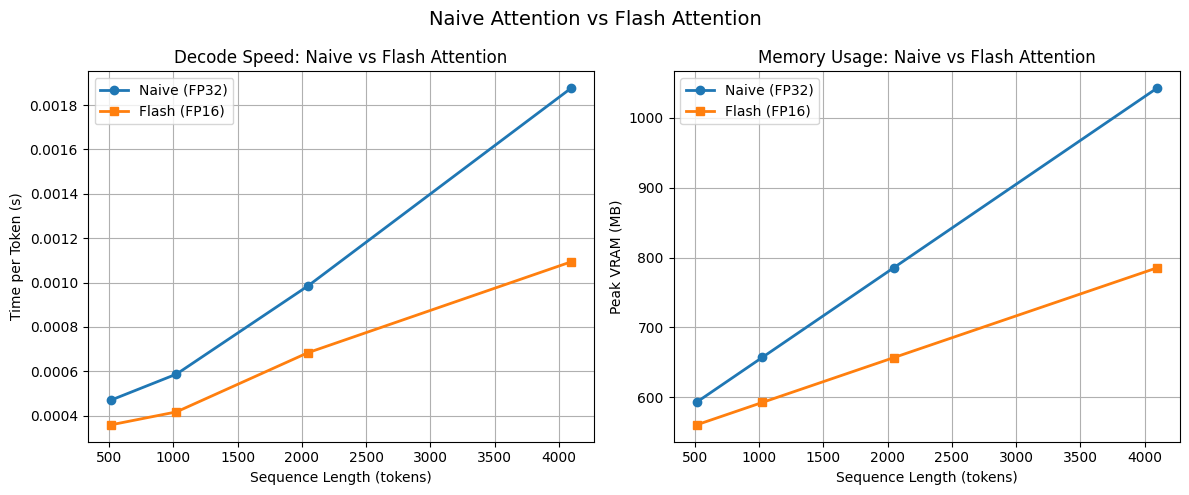

In [61]:
lengths_naive = [r[0] for r in results_naive]
tpt_naive = [r[2] for r in results_naive]
vram_naive = [r[3] for r in results_naive]

lengths_flash = [r[0] for r in results_flash]
tpt_flash = [r[2] for r in results_flash]
vram_flash = [r[3] for r in results_flash]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time per token comparison
axes[0].plot(lengths_naive, tpt_naive, marker='o', label='Naive (FP32)', linewidth=2)
axes[0].plot(lengths_flash, tpt_flash, marker='s', label='Flash (FP16)', linewidth=2)
axes[0].set_xlabel('Sequence Length (tokens)')
axes[0].set_ylabel('Time per Token (s)')
axes[0].set_title('Decode Speed: Naive vs Flash Attention')
axes[0].legend()
axes[0].grid(True)

# VRAM comparison
axes[1].plot(lengths_naive, vram_naive, marker='o', label='Naive (FP32)', linewidth=2)
axes[1].plot(lengths_flash, vram_flash, marker='s', label='Flash (FP16)', linewidth=2)
axes[1].set_xlabel('Sequence Length (tokens)')
axes[1].set_ylabel('Peak VRAM (MB)')
axes[1].set_title('Memory Usage: Naive vs Flash Attention')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Naive Attention vs Flash Attention', fontsize=14)
plt.tight_layout()
plt.show()

### My learnings

**What is Flash Attention?**  
Instead of computing the full $N \times N$ attention score matrix in GPU memory (HBM), Flash Attention tiles the computation — processing small blocks of Q, K, V in fast on-chip SRAM, never materializing the full matrix. The output is **mathematically identical** to naive attention, just computed smarter.

**What we see:**

| Length | Naive (ms/tok) | Flash (ms/tok) | Speedup | Naive VRAM | Flash VRAM | VRAM Saved |
|--------|---------------|----------------|---------|------------|------------|------------|
| 512    | 0.47          | 0.36           | 1.3×    | 593 MB     | 561 MB     | 5%         |
| 4096   | 1.88          | 1.09           | 1.7×    | 1042 MB    | 785 MB     | 25%        |

Both speed and memory gains **grow with sequence length** — exactly what you'd expect, since the avoided $N^2$ matrix gets larger.

#### ... I'm sorry I lied.....

**What actually ran on our T4:**  
In my defense, I only learnt this after implementation....Flash Attention's CUDA kernel requires **Ampere GPUs (A100, sm_80+)** for its `cp.async` memory instructions. Our T4 is Turing (sm_75), so PyTorch's SDPA silently fell back to the **memory-efficient attention** backend — a similar tiled approach that works on older hardware. We still got real gains because both avoid the full $N^2$ matrix, but true Flash Attention on an A100 would be even faster.

# Phase 5 : Navie Paged Attention

In [64]:
# Sanity check: clear GPU before a new phase implementation
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU memory: 518 MB allocated, 552 MB reserved


In [65]:
!nvidia-smi

Fri Feb 27 20:52:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             27W /   70W |     685MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [66]:
class PagedKVCache:
    def __init__(self, num_blocks, block_size, d_model, device):
        self.block_size = block_size
        self.device = device

        # Pre allocating fixed number of block for keys and values
        self.k_pool = torch.zeros(num_blocks, block_size, d_model, device=device)
        self.v_pool = torch.zeros(num_blocks, block_size, d_model, device=device)

        # Track which blocks are currently in use
        self.free_blocks = list(range(num_blocks))

        # Block table to map blocks with seq_id
        self.block_table = {}

        # Track tokens to be written per sequence
        self.seq_len = {}
    
    # Function to assign blocks
    def assign_blocks(self, seq_id):
        if not self.free_blocks:
            raise RuntimeError('Not enough memory blocks to store KV cache!')
        block_id = self.free_blocks.pop(0)
        if seq_id not in self.block_table:
            self.block_table[seq_id] = []
        self.block_table[seq_id].append(block_id)
        self.seq_len[seq_id] = 0 if seq_id not in self.seq_len else self.seq_len[seq_id]
        return block_id
    
    # Writing KV cache on to memory, main logic for PagedKV caching
    def write(self, seq_id, k_vec, v_vec):
        if seq_id not in self.block_table:
            self.assign_blocks(seq_id)
        
        block_id = self.block_table[seq_id][-1]
        slot = self.seq_len[seq_id] % self.block_size

        if slot == 0 and self.seq_len[seq_id] > 0:
            block_id = self.assign_blocks(seq_id)
        
        self.k_pool[block_id, slot] = k_vec
        self.v_pool[block_id, slot] = v_vec

        self.seq_len[seq_id] += 1
    
    # Function to reconstruct the original KV cache
    def read(self, seq_id):
        if seq_id not in self.block_table:
            return None, None

        blocks = self.block_table[seq_id]
        total_len = self.seq_len[seq_id]

        k_parts, v_parts = [], []

        for i, block_id in enumerate(blocks):
            if i < len(blocks) - 1:
                k_parts.append(self.k_pool[block_id])
                v_parts.append(self.v_pool[block_id])
            else:
                last_len = total_len % self.block_size
                if last_len == 0:
                    last_len = self.block_size
                k_parts.append(self.k_pool[block_id, :last_len])
                v_parts.append(self.v_pool[block_id, :last_len])
        
        return torch.cat(k_parts, dim = 0), torch.cat(v_parts, dim = 0)
    
    # Function to release the blocks when not needed
    def reset(self, seq_id):
        if seq_id in self.block_table:
            self.free_blocks.extend(self.block_table.pop(seq_id))
            self.seq_len.pop(seq_id)


In [67]:
@torch.no_grad()
def decode_with_paged_cache(model, input_ids, max_new_tokens, kv_cache, seq_id):
    model.eval()
    generated = input_ids

    for i in range(max_new_tokens):
        curr_input = generated if i == 0 else generated[:, -1:]

        past_k, past_v = kv_cache.read(seq_id)

        # Performing unsqueeze since out Model expects the dimesion of [B, T, d] 
        if past_k is not None:
            past_k = past_k.unsqueeze(0)
            past_v = past_v.unsqueeze(0)

        logits, (k, v) = model(curr_input, past_key_values=(past_k, past_v), use_cache=True)

        num_new = curr_input.shape[1]
        for t in range(num_new):
            kv_cache.write(seq_id, k[0, -num_new + t, :], v[0, -num_new + t, :])

        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)

    return generated

In [68]:
# --- Verification: observe block allocation and reuse ---

cache = PagedKVCache(num_blocks=8, block_size=4, d_model=512, device=device)
model_paged = SimpleInferenceModel(vocab_size, d_model).to(device)

print(f"Initial free blocks: {cache.free_blocks}\n")

# Run sequence 0: 5 prompt tokens + 10 new = 15 tokens total
# With block_size=4: needs ceil(15/4) = 4 blocks → [0, 1, 2, 3]
input_ids_0 = torch.randint(0, vocab_size, (1, 5)).to(device)
out0 = decode_with_paged_cache(model_paged, input_ids_0, max_new_tokens=10, kv_cache=cache, seq_id=0)

print(f"After seq 0 finishes:")
print(f"  block_table : {cache.block_table}")
print(f"  seq_len     : {cache.seq_len}")
print(f"  free_blocks : {cache.free_blocks}")
print(f"  output shape: {out0.shape}\n")   # should be [1, 15]

# Free seq 0 — its blocks should return to the pool
cache.reset(0)
print(f"After reset(0):")
print(f"  block_table : {cache.block_table}")
print(f"  free_blocks : {cache.free_blocks}\n")   # blocks [0,1,2,3] should be back

# Run sequence 1 — should REUSE blocks [0,1,2,3], not allocate new ones
input_ids_1 = torch.randint(0, vocab_size, (1, 5)).to(device)
out1 = decode_with_paged_cache(model_paged, input_ids_1, max_new_tokens=10, kv_cache=cache, seq_id=1)

print(f"After seq 1 finishes:")
print(f"  block_table : {cache.block_table}")
print(f"  free_blocks : {cache.free_blocks}")
print(f"  output shape: {out1.shape}")

Initial free blocks: [0, 1, 2, 3, 4, 5, 6, 7]

After seq 0 finishes:
  block_table : {0: [0, 1, 2, 3]}
  seq_len     : {0: 14}
  free_blocks : [4, 5, 6, 7]
  output shape: torch.Size([1, 15])

After reset(0):
  block_table : {}
  free_blocks : [4, 5, 6, 7, 0, 1, 2, 3]

After seq 1 finishes:
  block_table : {1: [4, 5, 6, 7]}
  free_blocks : [0, 1, 2, 3]
  output shape: torch.Size([1, 15])


Benchmarking memory Utilization

In [70]:
def benchmark_paged_memory(model, output_lengths, block_size=16, prompt_len=5):
    num_seqs  = len(output_lengths)
    max_total = prompt_len + max(output_lengths)  # worst-case tokens per seq

    # Size the pool to hold one sequence at peak (add 1 block of headroom)
    num_blocks = math.ceil(max_total / block_size) + 1
    cache = PagedKVCache(num_blocks, block_size, d_model, device)

    seq_results = []
    print(f"Pool: {num_blocks} blocks × {block_size} slots = {num_blocks * block_size} token capacity\n")
    print(f"{'Seq':<5} | {'Out Len':<8} | {'Tokens Written':<15} | {'Blocks Used':<12} | {'Free After Reset'}")
    print("-" * 65)

    for seq_id, out_len in enumerate(output_lengths):
        input_ids = torch.randint(0, vocab_size, (1, prompt_len)).to(device)
        decode_with_paged_cache(model, input_ids, out_len, cache, seq_id)

        tokens_written = cache.seq_len[seq_id]
        blocks_used    = len(cache.block_table[seq_id])

        cache.reset(seq_id)

        free_after = len(cache.free_blocks)
        seq_results.append((seq_id, out_len, tokens_written, blocks_used))
        print(f"{seq_id:<5} | {out_len:<8} | {tokens_written:<15} | {blocks_used:<12} | {free_after}")

    # Memory comparison (K + V, float32 = 4 bytes)
    bytes_per_token  = d_model * 2 * 4
    paged_pool_mb    = num_blocks * block_size * bytes_per_token / 1024**2
    
    num_seqs = len(output_lengths)
    naive_total_mb = num_seqs * max_total * bytes_per_token / 1024**2
    actual_mb = sum([out_len * bytes_per_token / 1024**2 for out_len in output_lengths])

    print(f"Naive total (all seqs at max_len) : {naive_total_mb:.2f} MB")
    print(f"Paged pool (fixed, reused)        : {paged_pool_mb:.2f} MB")
    print(f"Actual data written               : {actual_mb:.2f} MB")

    return seq_results, paged_pool_mb, naive_total_mb, actual_mb

In [71]:
model_paged = SimpleInferenceModel(vocab_size, d_model).to(device)
output_lengths = [512, 1024, 4096, 2048, 256]

seq_results, paged_mb, naive_mb, actual_mb = benchmark_paged_memory(
    model_paged, output_lengths, block_size=16
)

Pool: 258 blocks × 16 slots = 4128 token capacity

Seq   | Out Len  | Tokens Written  | Blocks Used  | Free After Reset
-----------------------------------------------------------------
0     | 512      | 516             | 33           | 258
1     | 1024     | 1028            | 65           | 258
2     | 4096     | 4100            | 257          | 258
3     | 2048     | 2052            | 129          | 258
4     | 256      | 260             | 17           | 258
Naive total (all seqs at max_len) : 80.10 MB
Paged pool (fixed, reused)        : 16.12 MB
Actual data written               : 31.00 MB


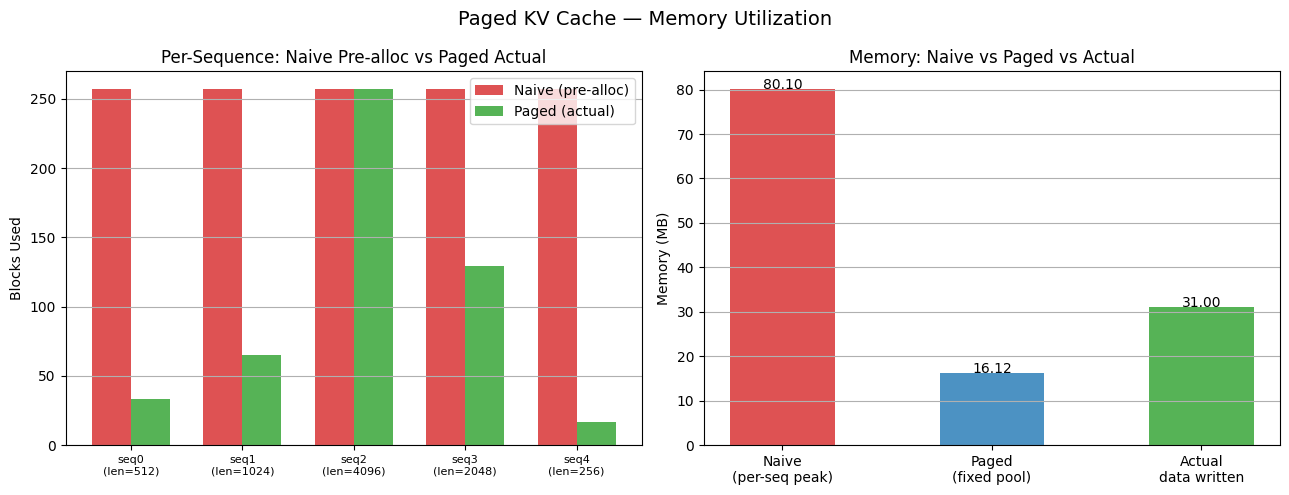

In [72]:
seq_ids      = [r[0] for r in seq_results]
out_lens     = [r[1] for r in seq_results]
blocks_used  = [r[3] for r in seq_results]

# Naive blocks needed = ceil(total_tokens / block_size)  per sequence
prompt_len = 5
block_size = 16

# Naive must pre-allocate max_total for EVERY sequence, not just the actual length
max_total = prompt_len + max(out_lens)   # = 5 + 4096 = 4101
naive_blocks_per_seq = math.ceil(max_total / block_size)  # = ceil(4101/16) = 257
naive_blocks = [naive_blocks_per_seq] * len(seq_ids)       # [257, 257, 257, 257, 257]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-sequence blocks used vs naive
x = range(len(seq_ids))
w = 0.35
axes[0].bar([i - w/2 for i in x], naive_blocks, width=w, label='Naive (pre-alloc)', color='tab:red',    alpha=0.8)
axes[0].bar([i + w/2 for i in x], blocks_used,  width=w, label='Paged (actual)',    color='tab:green',  alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"seq{i}\n(len={l})" for i, l in zip(seq_ids, out_lens)], fontsize=8)
axes[0].set_ylabel('Blocks Used')
axes[0].set_title('Per-Sequence: Naive Pre-alloc vs Paged Actual')
axes[0].legend()
axes[0].grid(axis='y')

# Right: summary memory bar
labels_mem = ['Naive\n(per-seq peak)', 'Paged\n(fixed pool)', 'Actual\ndata written']
values_mem = [naive_mb, paged_mb, actual_mb]
colors     = ['tab:red', 'tab:blue', 'tab:green']
axes[1].bar(labels_mem, values_mem, color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('Memory (MB)')
axes[1].set_title('Memory: Naive vs Paged vs Actual')
axes[1].grid(axis='y')
for i, v in enumerate(values_mem):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=10)

plt.suptitle('Paged KV Cache — Memory Utilization', fontsize=14)
plt.tight_layout()
plt.show()

### My learnings

This is a simplified version of the PagedAttention mechanism used by [vLLM](https://github.com/vllm-project/vllm). The core concepts demonstrated here are:
- **Block-based allocation:** KV cache is stored in fixed-size blocks, assigned on-demand as a sequence grows
- **Block reuse:** When a sequence finishes, its blocks return to the pool for the next request
- **No pre-allocation waste:** Instead of reserving max-length memory for every sequence, we only allocate what's actually needed

In production, frameworks like vLLM take this further with a **scheduler** that manages multiple concurrent requests sharing the same block pool simultaneously. The scheduler decides which sequences to run each step, preempts low-priority requests when memory is tight (freeing their blocks), and resumes them later — essentially acting as an OS-level memory manager for GPU KV cache. Our sequential benchmark wouldn't capture this, but the underlying block allocation logic is the same.

# Phase - 6 : Speculative Decoding

In [4]:
# Clear everything before Phase 6
import gc

# Delete any lingering models from previous phases
for var_name in ['model', 'model_full', 'model_window', 'model_naive', 'model_flash', 
                 'model_paged', 'gpt2_model', 'model_naive_warmup', 'model_flash_warmup']:
    if var_name in dir():
        exec(f'del {var_name}')

gc.collect()
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated")

GPU memory: 0 MB allocated


In [5]:
!nvidia-smi

Sat Feb 28 23:18:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [7]:
draft_model_id = 'Qwen/Qwen2.5-0.5B-Instruct'
draft_model = AutoModelForCausalLM.from_pretrained(draft_model_id).to(device).eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [8]:
target_model_id = 'Qwen/Qwen2.5-1.5B-Instruct'
target_model = AutoModelForCausalLM.from_pretrained(target_model_id).to(device).eval()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [9]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-1.5B-Instruct')

In [10]:
print(f"Draft  params: {sum(p.numel() for p in draft_model.parameters()) / 1e6:.0f}M")
print(f"Target params: {sum(p.numel() for p in target_model.parameters()) / 1e6:.0f}M")

Draft  params: 494M
Target params: 1544M


In [11]:
@torch.no_grad()
def draft_decode(draft_model, input_ids, K, past=None):
    curr_ip = input_ids if past is None else input_ids[:, -1:]
    output = draft_model(curr_ip, past_key_values = past, use_cache = True)
    past = output.past_key_values

    draft_tokens, draft_probs = [], []

    for _ in range(K):
        probs = torch.softmax(output.logits[:, -1, :], dim = -1)  #[1, vocab_size]
        next_token = torch.argmax(probs, dim=-1, keepdim = True)  #[1,1]

        draft_tokens.append(next_token.squeeze())
        draft_probs.append(probs.squeeze(0))

        output = draft_model(next_token, past_key_values=past, use_cache=True)
        past = output.past_key_values
    
    return torch.stack(draft_tokens), torch.stack(draft_probs), past

In [12]:
@torch.no_grad()
def verify_drafts(target_model, input_ids, draft_tokens, past=None):
    K = draft_tokens.shape[0]
    
    # If we have cached KV from previous iterations, only process new tokens
    if past is not None:
        # Feed the last token of input_ids + all draft tokens
        verify_input = torch.cat([input_ids[:, -1:], draft_tokens.unsqueeze(0)], dim=1)
    else:
        verify_input = torch.cat([input_ids, draft_tokens.unsqueeze(0)], dim=1)
    
    outputs = target_model(verify_input, past_key_values=past, use_cache=True)
    
    # The last K+1 logits correspond to positions we need to verify
    # (position before first draft token through last draft token)
    logits = outputs.logits[0, -(K+1):, :]
    target_probs = torch.softmax(logits[:K], dim=-1)
    bonus_probs = torch.softmax(logits[K:], dim=-1)
    
    return target_probs, bonus_probs, outputs.past_key_values

In [13]:
@torch.no_grad()
def speculative_decode(draft_model, target_model, input_ids, max_new_tokens, K=3):
    generated = input_ids.clone()
    total_accepted, total_drafted = 0, 0

    while (generated.shape[1] - input_ids.shape[1]) < max_new_tokens:
        remaining = max_new_tokens - (generated.shape[1] - input_ids.shape[1])
        k = min(K, remaining)

        # Draft K tokens (cheap model, no cache reuse — draft is small enough)
        draft_tokens, draft_probs, _ = draft_decode(draft_model, generated, k, past=None)

        # Verify all K tokens in ONE target forward pass (the key win)
        verify_input = torch.cat([generated, draft_tokens.unsqueeze(0)], dim=1)
        outputs = target_model(verify_input, use_cache=False)
        T = generated.shape[1]
        target_probs = torch.softmax(outputs.logits[0, T-1:T+k, :], dim=-1)

        n_accepted = 0
        new_token = None

        for i in range(k):
            p_t = target_probs[i, draft_tokens[i]]
            p_d = draft_probs[i, draft_tokens[i]]

            if torch.rand(1, device=device).item() < min(1.0, (p_t / p_d).item()):
                n_accepted += 1
            else:
                residual = torch.clamp(target_probs[i] - draft_probs[i], min=0.0)
                new_token = torch.multinomial(residual / residual.sum(), 1).item()
                break
        else:
            bonus_probs = torch.softmax(outputs.logits[0, T+k-1, :], dim=-1)
            new_token = torch.multinomial(bonus_probs, 1).item()

        if n_accepted > 0:
            generated = torch.cat([generated, draft_tokens[:n_accepted].unsqueeze(0)], dim=1)
        generated = torch.cat([generated, torch.tensor([[new_token]], device=device)], dim=1)

        total_accepted += n_accepted
        total_drafted += k

    generated = generated[:, :input_ids.shape[1] + max_new_tokens]
    acceptance_rate = total_accepted / total_drafted if total_drafted > 0 else 0.0
    return generated, acceptance_rate

In [15]:
@torch.no_grad()
def target_only_decode(target_model, input_ids, max_new_tokens):
    generated = input_ids.clone()
    for i in range(max_new_tokens):
        outputs = target_model(generated, use_cache=False)
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
    return generated

def benchmark_speculative(prompt, max_new_tokens=60, K_values=[4, 8, 12]):
    input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
    results = []

    # === Warmup both code paths ===
    _ = target_only_decode(target_model, input_ids, 20)
    _ = speculative_decode(draft_model, target_model, input_ids, 20, K=4)
    torch.cuda.synchronize()

    start = time.time()
    _ = target_only_decode(target_model, input_ids, max_new_tokens)
    torch.cuda.synchronize()
    t = time.time() - start
    tps = max_new_tokens / t
    results.append({'label': 'Target only', 'tps': tps, 'acc_rate': None})
    print(f"Target only  : {tps:.1f} tok/s")

    for K in K_values:
        torch.cuda.synchronize()
        start = time.time()
        _, acc = speculative_decode(draft_model, target_model, input_ids, max_new_tokens, K=K)
        torch.cuda.synchronize()
        t = time.time() - start
        tps = max_new_tokens / t
        results.append({'label': f'Spec K={K}', 'tps': tps, 'acc_rate': acc})
        print(f"Spec K={K:2d}     : {tps:.1f} tok/s  | acceptance={acc:.1%}")

    return results

prompt = "In a far distant land"
spec_results = benchmark_speculative(prompt, max_new_tokens=512, K_values=[4, 8, 12])

Target only  : 2.5 tok/s
Spec K= 4     : 7.0 tok/s  | acceptance=87.9%
Spec K= 8     : 8.5 tok/s  | acceptance=70.8%
Spec K=12     : 8.2 tok/s  | acceptance=53.2%


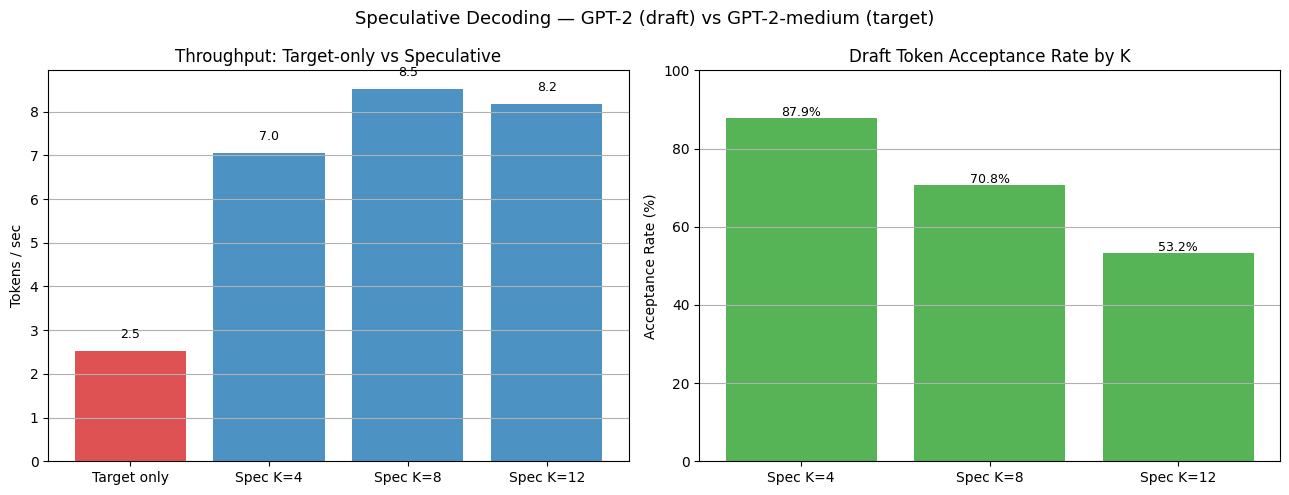

In [16]:
labels   = [r['label'] for r in spec_results]
tps_vals = [r['tps'] for r in spec_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['tab:red'] + ['tab:blue'] * (len(labels) - 1)
axes[0].bar(labels, tps_vals, color=colors, alpha=0.8)
for i, v in enumerate(tps_vals):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)
axes[0].set_ylabel('Tokens / sec')
axes[0].set_title('Throughput: Target-only vs Speculative')
axes[0].grid(axis='y')

spec_labels = [r['label'] for r in spec_results if r['acc_rate'] is not None]
spec_accs   = [r['acc_rate'] * 100 for r in spec_results if r['acc_rate'] is not None]
axes[1].bar(spec_labels, spec_accs, color='tab:green', alpha=0.8)
for i, v in enumerate(spec_accs):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_title('Draft Token Acceptance Rate by K')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y')

plt.suptitle('Speculative Decoding — GPT-2 (draft) vs GPT-2-medium (target)', fontsize=13)
plt.tight_layout()
plt.show()

### My Learnings

**Why Qwen?** We use `Qwen2.5-0.5B-Instruct` (draft) and `Qwen2.5-1.5B-Instruct` (target) — same architecture, same tokenizer, same training family. This maximizes draft-target agreement, which is the single biggest lever for speculative decoding performance.

**Results (512 new tokens):**

| Method | Tok/s | Speedup | Acceptance Rate |
|--------|-------|---------|-----------------|
| Target only | 2.5 | 1× | — |
| Spec K=4 | 7.0 | 2.8× | 87.9% |
| **Spec K=8** | **8.5** | **3.4×** | **70.8%** |
| Spec K=12 | 8.2 | 3.3× | 53.2% |

**K=8 is the sweet spot.** Going from K=4 to K=8 gains 21% more throughput. Going from K=8 to K=12 actually *loses* throughput — acceptance drops to 53%, meaning nearly half the draft tokens are wasted, and the extra draft compute costs more than it saves.

**Key insight:** Speculative decoding trades cheap draft compute for expensive target compute. It works as long as the acceptance rate is high enough that the draft overhead pays for itself. Once acceptance drops below ~60%, the savings from fewer target iterations are eaten by wasted draft work — which is exactly what we see at K=12.


# Phase - 7 : Model Quantization

In [4]:
# Clear everything before Phase 6
import gc

# Delete any lingering models from previous phases
for var_name in ['model', 'model_full', 'model_window', 'model_naive', 'model_flash', 
                 'model_paged', 'gpt2_model', 'model_naive_warmup', 'model_flash_warmup']:
    if var_name in dir():
        exec(f'del {var_name}')

gc.collect()
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated")

GPU memory: 0 MB allocated


In [4]:
!pip install -q bitsandbytes accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00:00:0100:01


In [6]:
!nvidia-smi

Tue Mar  3 18:07:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Why switch from GPT-2?** 

GPT-2 is a *base model* — it was trained to autocomplete text, not follow instructions. For quantization, we need to compare generation quality across FP16/INT8/INT4, which requires a model that can actually follow prompts. We switch to `Qwen2.5-1.5B-Instruct` (instruction-tuned) so we can meaningfully evaluate whether quantization degrades output quality — something we can't test with a model that just repeats the prompt back.

**Why Qwen specifically?** The Qwen2.5 family comes in sizes from 0.5B to 72B — all sharing the same architecture and tokenizer. This means we can pair `Qwen2.5-1.5B-Instruct` with `Qwen2.5-0.5B` as a draft model for speculative decoding during deployment, getting high acceptance rates because same-family models agree well on token distributions.

In [7]:
import torch
import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_id = 'Qwen/Qwen2.5-1.5B-Instruct'
# model_id = 'gpt2-xl'

In [9]:
@torch.no_grad()
def compute_perplexity(model, tokenizer, max_length=512, stride=256, max_samples=512):
    """Compute perplexity on WikiText-2 test set using sliding window."""
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    text = "\n\n".join([t for t in dataset["text"] if t.strip()])
    encodings = tokenizer(text, return_tensors="pt")
    input_ids = encodings.input_ids[:, :max_samples * stride]

    nlls = []
    for begin in range(0, input_ids.size(1) - max_length, stride):
        end = begin + max_length
        chunk = input_ids[:, begin:end].to(model.device)
        target = chunk.clone()
        target[:, :-stride] = -100  # only score the stride portion

        outputs = model(chunk, labels=target)
        nlls.append(outputs.loss.item())

    ppl = torch.exp(torch.tensor(nlls).mean()).item()
    return ppl

In [10]:
def benchmark_model(model, tokenizer, label, prompts, max_new_tokens=100):
    """Measure memory, latency, perplexity, and sample outputs."""
    # Model memory
    model_mem = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2

    # Latency: average over prompts
    torch.cuda.reset_peak_memory_stats()
    latencies = []
    outputs_text = []

    for prompt in prompts:
        messages = [{"role": "user", "content": prompt}]
        if getattr(tokenizer, "chat_template", None):
            messages = [{"role": "user", "content": prompt}]
            text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        else:
            text = prompt
        input_ids = tokenizer(text, return_tensors="pt").input_ids.to(model.device)

        torch.cuda.synchronize()
        start = time.time()
        out = model.generate(input_ids, max_new_tokens=max_new_tokens, do_sample=False)
        torch.cuda.synchronize()
        latencies.append(time.time() - start)

        generated = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
        outputs_text.append(generated)

    peak_vram = torch.cuda.max_memory_allocated() / 1024**2
    avg_latency = sum(latencies) / len(latencies)
    tokens_per_sec = max_new_tokens / avg_latency

    # Perplexity
    print(f"  [{label}] Computing perplexity...")
    ppl = compute_perplexity(model, tokenizer)
    result = {
        'label': label,
        'model_mem_mb': model_mem,
        'peak_vram_mb': peak_vram,
        'avg_latency_s': avg_latency,
        'tokens_per_sec': tokens_per_sec,
        'perplexity': ppl,
        'outputs': outputs_text,
    }

    print(f"  [{label}] Memory: {model_mem:.0f} MB | "
          f"Latency: {avg_latency:.2f}s | "
          f"Tok/s: {tokens_per_sec:.1f} | "
          f"PPL: {ppl:.2f} | "
          f"Peak VRAM: {peak_vram:.0f} MB")

    return result

In [11]:
eval_prompts = [
    "Write a single paragraph moral story for children about a rabbit who learns the value of sharing.",
    "Write a single paragraph  moral story for children about a little star that was afraid of the dark.",
    "Write a single paragraph  moral story for children about two friends who solve a problem by working together.",
]

def free_model(model):
    """Properly free a model loaded with device_map='auto'."""
    # Remove accelerate dispatch hooks if present
    if hasattr(model, '_hf_hook'):
        from accelerate.hooks import remove_hook_from_module
        remove_hook_from_module(model, recurse=True)
    
    del model
    gc.collect()
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
    print(f"  GPU allocated after free: {torch.cuda.memory_allocated() / 1024**2:.0f} MB")


In [12]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
print("=" * 60)
print("Loading FP16 baseline...")

model_fp16 = AutoModelForCausalLM.from_pretrained(
    model_id, dtype=torch.float16, device_map="auto"
)
result_fp16 = benchmark_model(model_fp16, tokenizer, "FP16", eval_prompts)
free_model(model_fp16)

Loading FP16 baseline...


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 131072). Running this sequence through the model will result in indexing errors


  [FP16] Memory: 2944 MB | Latency: 4.77s | Tok/s: 21.0 | PPL: 9.72 | Peak VRAM: 2962 MB
  GPU allocated after free: 2954 MB


In [17]:
!nvidia-smi

Sat Feb 28 22:35:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             29W /   70W |    3081MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
model_fp16.to("cpu")
del model_fp16

gc.collect()
torch.cuda.empty_cache()

In [18]:
print(torch.cuda.memory_allocated()/1024**2)

9.125


In [19]:
print("=" * 60)
print("Loading INT8 (W8A16)...")
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False,
)
model_int8 = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=quantization_config, device_map="auto"
)
result_int8 = benchmark_model(model_int8, tokenizer, "INT8", eval_prompts)
free_model(model_int8)

Loading INT8 (W8A16)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


  [INT8] Computing perplexity...
  [INT8] Memory: 1695 MB | Latency: 18.99s | Tok/s: 5.3 | PPL: 9.79 | Peak VRAM: 1725 MB
  GPU allocated after free: 1708 MB


In [25]:
!nvidia-smi

Sat Feb 28 22:41:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             30W /   70W |    3089MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
for _ in range(3):
    gc.collect()

In [22]:
torch.cuda.reset_peak_memory_stats()

In [23]:
model_int8.to("cpu")
del model_int8

gc.collect()
torch.cuda.empty_cache()

In [24]:
print(torch.cuda.memory_allocated()/1024**2)

9.125


In [ ]:
print("=" * 60)
print("Loading INT4 (W4A16 NF4)...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model_int4 = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=bnb_config, dtype=torch.bfloat16, device_map="auto"
)
result_int4 = benchmark_model(model_int4, tokenizer, "INT4", eval_prompts)
free_model(model_int4)

Loading INT4 (W4A16 NF4)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  [INT4] Computing perplexity...
  [INT4] Memory: 1070 MB | Latency: 8.01s | Tok/s: 12.5 | PPL: 10.53 | Peak VRAM: 1134 MB
  GPU allocated after free: 1104 MB


In [30]:
!nvidia-smi

Sat Feb 28 22:50:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             30W /   70W |    3089MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
model_int4.to("cpu")
del model_int4

gc.collect()
torch.cuda.empty_cache()

In [29]:
print(torch.cuda.memory_allocated()/1024**2)

9.1259765625


In [31]:
all_results = [result_fp16, result_int8, result_int4]

print(f"\n{'Config':<8} | {'Model MB':<10} | {'Peak VRAM':<10} | {'Latency':<9} | {'Tok/s':<8} | {'PPL':<8}")
print("-" * 65)
for r in all_results:
    print(f"{r['label']:<8} | {r['model_mem_mb']:<10.0f} | {r['peak_vram_mb']:<10.0f} | "
          f"{r['avg_latency_s']:<9.2f} | {r['tokens_per_sec']:<8.1f} | {r['perplexity']:<8.2f}")


Config   | Model MB   | Peak VRAM  | Latency   | Tok/s    | PPL     
-----------------------------------------------------------------
FP16     | 2944       | 2962       | 4.77      | 21.0     | 9.72    
INT8     | 1695       | 1725       | 18.99     | 5.3      | 9.79    
INT4     | 1070       | 1134       | 8.01      | 12.5     | 10.53   


In [30]:
for i, prompt in enumerate(eval_prompts):
    print(f"\n{'='*70}")
    print(f"PROMPT: {prompt}\n")
    for r in all_results:
        print(f"[{r['label']}]: {r['outputs'][i][:200]}...")
        print()


PROMPT: Write a single paragraph moral story for children about a rabbit who learns the value of sharing.

[FP16]: In a lush meadow, lived a little rabbit named Pip. Pip was a curious creature, always eager to explore the world around him. One sunny afternoon, while scampering through the grass, Pip stumbled upon ...

[INT8]: In a lush meadow, lived a curious rabbit named Sammy. Sammy was known for his generosity and always shared what he had with others. He would share his juicy carrots with the hungry birds, his fluffy f...

[INT4]: Once upon a time, there was a little rabbit named Rosie who was known throughout the meadow for her generosity. She always shared her food with the other animals, whether it was a juicy carrot or a ha...


PROMPT: Write a single paragraph  moral story for children about a little star that was afraid of the dark.

[FP16]: In a vast expanse of the night sky, lived a little star named Stella. Unlike her twinkling companions, Stella was terrified of the dark

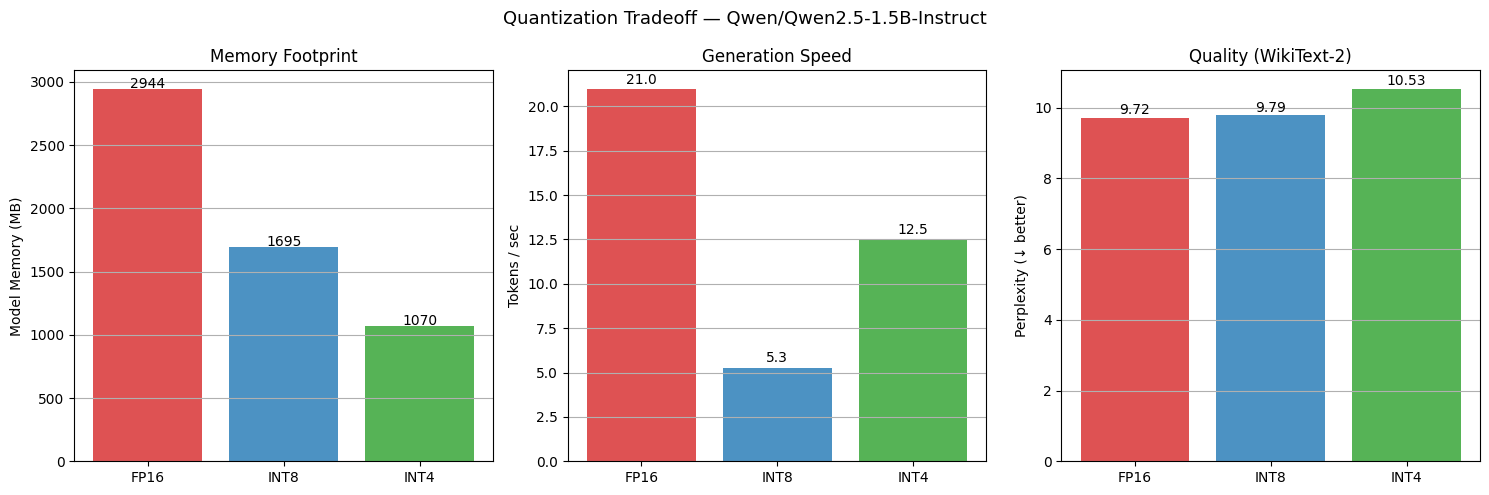

In [32]:
import matplotlib.pyplot as plt

labels = [r['label'] for r in all_results]
mems   = [r['model_mem_mb'] for r in all_results]
tps    = [r['tokens_per_sec'] for r in all_results]
ppls   = [r['perplexity'] for r in all_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Memory
colors = ['tab:red', 'tab:blue', 'tab:green']
axes[0].bar(labels, mems, color=colors, alpha=0.8)
for i, v in enumerate(mems):
    axes[0].text(i, v + 10, f'{v:.0f}', ha='center', fontsize=10)
axes[0].set_ylabel('Model Memory (MB)')
axes[0].set_title('Memory Footprint')
axes[0].grid(axis='y')

# Tokens/sec
axes[1].bar(labels, tps, color=colors, alpha=0.8)
for i, v in enumerate(tps):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)
axes[1].set_ylabel('Tokens / sec')
axes[1].set_title('Generation Speed')
axes[1].grid(axis='y')

# Perplexity
axes[2].bar(labels, ppls, color=colors, alpha=0.8)
for i, v in enumerate(ppls):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)
axes[2].set_ylabel('Perplexity (↓ better)')
axes[2].set_title('Quality (WikiText-2)')
axes[2].grid(axis='y')

plt.suptitle(f'Quantization Tradeoff — {model_id}', fontsize=13)
plt.tight_layout()
plt.show()

### My Learnings

| Config | Model MB | Peak VRAM | Latency (s) | Tok/s | PPL |
|--------|---------|-----------|-------------|-------|-----|
| FP16   | 2944    | 2962      | 4.77        | 21.0  | 9.72 |
| INT8   | 1695    | 1725      | 18.99       | 5.3   | 9.79 |
| INT4   | 1070    | 1134      | 8.01        | 12.5  | 10.53 |

**Why INT4 wins for deployment:** With weight-only quantization (W4A16), weights are stored in 4-bit but dequantized to FP16/BF16 for actual computation. This gives us **64% memory savings** (1070 MB vs 2944 MB) with only a minor quality cost (PPL 10.53 vs 9.72 — an 8% increase that is barely perceptible in generated text). The model fits comfortably on a single T4 with room to spare for KV cache and batching.

**Why INT8 is the slowest:** The T4 (Turing architecture) lacks native INT8 tensor cores, so INT8 inference requires constant dequantize → compute → requantize overhead on every operation. INT4 (NF4) avoids this by dequantizing once to BF16 and staying there — which is why INT4 is actually **2.4× faster** than INT8 on our hardware. Meanwhile, INT8 barely saves quality over FP16 (PPL 9.79 vs 9.72) while being **4× slower** — the worst trade-off of the three.

### Evaluation: Why Perplexity?

For open-ended **long-form generation**, perplexity on a held-out corpus (WikiText-2) measures how well the model predicts natural text — a direct proxy for language fluency and coherence. Unlike classification benchmarks (e.g., MMLU), perplexity doesn't require the model to follow a specific answer format, making it the right metric for story generation quality.

**Takeaway:** Quantization performance is hardware-dependent. On newer GPUs (Ampere/Hopper) with native INT8 support, INT8 would be faster. On T4, INT4 with NF4 is the practical sweet spot — smallest memory footprint, best speed, and the small PPL increase (< 1 point) is an acceptable trade-off for a 64% memory reduction and 2.4× speedup over INT8.

# Phase 8: Attention Variants — MHA, MQA, GQA, and MLA

In Phases 1–4 we built attention from scratch and saw how KV caching and Flash Attention optimize *execution*. But there's a completely different axis of optimization: **how many key/value heads does the model actually need?**

This phase surveys the four major attention architectures used in modern LLMs. We won't implement them from scratch — these are architectural choices baked into model training — but understanding them is essential for reasoning about inference cost.

## 8.1 Multi-Head Attention (MHA)

This is the original Transformer design (Vaswani et al., 2017) and what we implemented in Phase 1.

**How it works:**  
Each attention layer has $h$ independent heads. Every head gets its own Query, Key, and Value projection:

$$Q_i = xW_i^Q, \quad K_i = xW_i^K, \quad V_i = xW_i^V \quad \text{for } i = 1, \dots, h$$

**KV cache cost per layer per token:**  
$$2 \times h \times d_{\text{head}} \times \text{sizeof(dtype)}$$

For a model with 32 heads and $d_{\text{head}} = 128$ in FP16:  
$2 \times 32 \times 128 \times 2 = 16{,}384$ bytes per layer per token.

**Used by:** GPT-2, GPT-3, BERT, original LLaMA-1

**Trade-off:** Maximum expressiveness, but KV cache grows linearly with $h$ — becomes the bottleneck at long contexts and large batch sizes.

## 8.2 Multi-Query Attention (MQA)

Introduced by [Shazeer (2019)](https://arxiv.org/abs/1911.02150), MQA is brutal in its simplicity: **all heads share a single K and V projection**, while each head still gets its own Q.

$$Q_i = xW_i^Q \quad \text{(per head)}, \quad K = xW^K, \quad V = xW^V \quad \text{(shared)}$$

**KV cache cost per layer per token:**  
$$2 \times 1 \times d_{\text{head}} \times \text{sizeof(dtype)}$$

That's a $\mathbf{32\times}$ reduction compared to MHA (for a 32-head model).

**Used by:** PaLM, Falcon, StarCoder, Gemma 

**Trade-off:** Massive KV cache savings and decode speedup. Quality is slightly lower than MHA in some benchmarks, but the inference efficiency gain is enormous — especially for high-throughput serving.

## 8.3 Grouped-Query Attention (GQA)

[Ainslie et al. (2023)](https://arxiv.org/abs/2305.13245) proposed GQA as a middle ground: instead of 1 KV head (MQA) or $h$ KV heads (MHA), use $g$ groups where $1 < g < h$. Each group of $h/g$ query heads shares one K and one V head.

$$Q_i = xW_i^Q, \quad K_j = xW_j^K, \quad V_j = xW_j^V \quad \text{where } j = \lfloor i \cdot g / h \rfloor$$

**KV cache cost per layer per token:**  
$$2 \times g \times d_{\text{head}} \times \text{sizeof(dtype)}$$

For 32 query heads with $g = 8$ groups: KV cache is $4\times$ smaller than MHA, but $8\times$ larger than MQA.

**Used by:** Llama 2 (70B), Llama 3, Mistral, Mixtral, DeepSeek-V1

**Trade-off:** The "Goldilocks" approach — recovers most of MHA's quality while capturing most of MQA's speed benefit. This is currently the most popular choice for new large-scale models.

## 8.4 Multi-Head Latent Attention (MLA)

[DeepSeek-V2 (2024)](https://arxiv.org/abs/2405.04434) introduced MLA, which takes a fundamentally different approach: instead of reducing the *number* of KV heads, it compresses the KV cache using **low-rank projections**.

**How it works:**
1. Project the hidden state into a small **latent vector** $c_t \in \mathbb{R}^{d_c}$ where $d_c \ll h \times d_{\text{head}}$
2. Cache only $c_t$ (not full K, V)
3. At decode time, reconstruct K and V from $c_t$ using learned up-projections

$$c_t = xW^{DKV}, \quad K = c_t W^{UK}, \quad V = c_t W^{UV}$$

**KV cache cost per layer per token:**  
$$d_c \times \text{sizeof(dtype)}$$

DeepSeek-V2 uses $d_c = 512$ vs MHA's $h \times d_\text{head} = 16{,}384$ — a $\mathbf{32\times}$ compression, same as MQA, but without sacrificing head diversity.

**Used by:** DeepSeek-V2, DeepSeek-V3

**Trade-off:** Achieves MQA-level cache efficiency with MHA-level quality, but adds compute overhead for the up-projection during decode. The approach is newer and less battle-tested than GQA.

## 8.5 Comparison

| Variant | KV Heads | Cache per Layer per Token | Quality | Notable Models |
|---------|----------|--------------------------|---------|----------------|
| **MHA** | $h$ | $2 \times h \times d_{\text{head}}$ | Baseline | GPT-3, LLaMA-1 |
| **MQA** | 1 | $2 \times d_{\text{head}}$ | Slight ↓ | PaLM, Falcon, Gemma |
| **GQA** | $g$ | $2 \times g \times d_{\text{head}}$ | ≈ MHA | Llama 2/3, Mistral, **Qwen2.5** |
| **MLA** | N/A (latent) | $d_c$ | ≈ MHA | DeepSeek-V2/V3 |

**Where our model fits:** Qwen2.5-1.5B-Instruct uses **GQA** with 2 KV heads (out of 12 total attention heads), giving a 6× KV cache reduction compared to full MHA. This strikes a balance — more expressive than MQA's single KV head, while still keeping the cache small enough to run comfortably on T4. Combined with our INT4 quantization decision from Phase 7, the model is well-suited for memory-constrained deployment.

The industry trend is moving from MHA → GQA for most new models, with MLA as an emerging alternative for very large-scale systems where KV cache dominates serving cost.

# Phase 9: Conclusion — From Scratch to Deployment



Based on our benchmarks across Phases 1–8, here is the optimal stack for our **children's moral story generation** service:

| Component | Choice | Why |
|-----------|--------|-----|
| **Model** | Qwen2.5-1.5B-Instruct | Instruction-tuned, GQA architecture (2 KV heads), compact KV cache |
| **Quantization** | INT4 (NF4 + double quant) | 64% memory savings (1070 MB vs 2944 MB), minimal quality cost (PPL 10.53 vs 9.72) |
| **Inference** | KV Cache + SDPA + Paged Attention | Free speedup, efficient multi-user memory management |
| **Speculative Decoding** | Qwen2.5-0.5B-Instruct as draft model | Same-family draft for high acceptance rates (70.8% at K=8, 3.4× speedup) |
| **Infrastructure** | 2–8× T4 GPUs, Kubernetes HPA | Autoscale at 70% GPU utilization |

Next step: deploy this stack and validate it under load with 100K+ real-world queries.